In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load the dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame

# View data
data.head()
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


20640


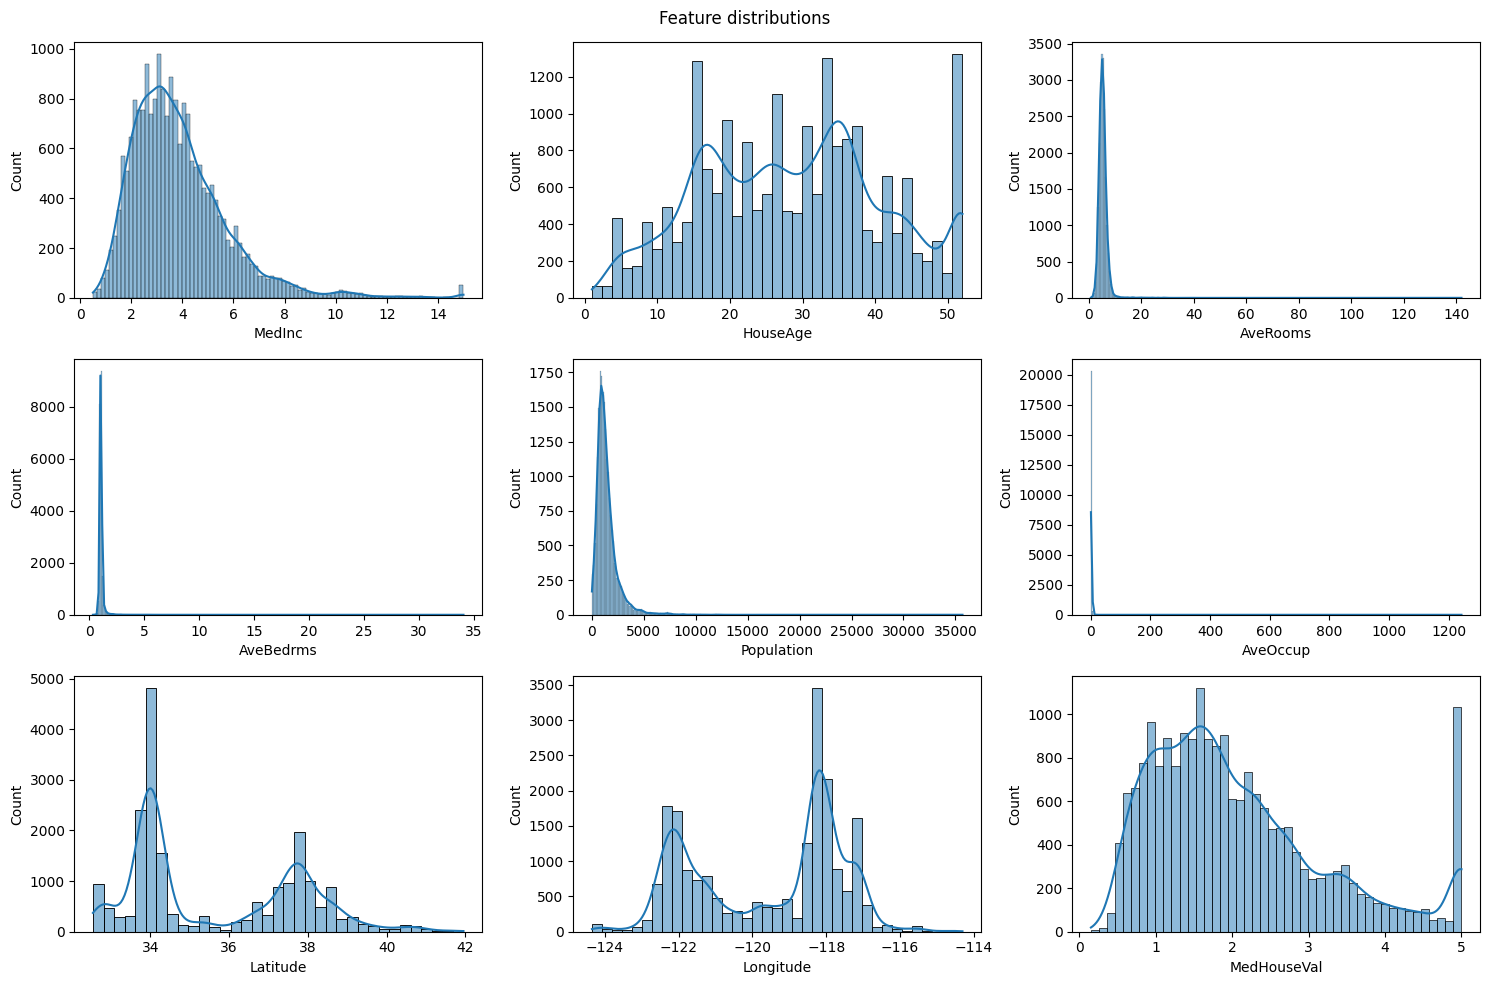

In [8]:
# Visualize correlations between features and house prices

fig1, axes1 = plt.subplots(3, 3, figsize=(15, 10))
fig1.suptitle('Feature distributions')
for i, axe in enumerate(axes1.ravel()):
    col = data.columns[i]
    sns.histplot(data[col], kde=True, ax=axe)
plt.tight_layout()

print(len(data))

# fig2, axes2 = plt.subplots(3, 3, figsize=(15, 10))
# fig2.suptitle('Feature / Target scatter')
# for i, axe in enumerate(axes2.ravel()):
#     col = data.columns[i]
#     axe.scatter(data[col], data['MedHouseVal'], alpha=.3)
#     axe.set_xlabel(col)

# plt.tight_layout()

# fig3, axes3 = plt.subplots(figsize=(10, 6))
# sns.heatmap(data.corr(), annot=True, ax=axes3, fmt=".2f", cmap="coolwarm")
# axes3.set_title('Correlation Matrix')

plt.tight_layout()


# sns.pairplot(data)


15922


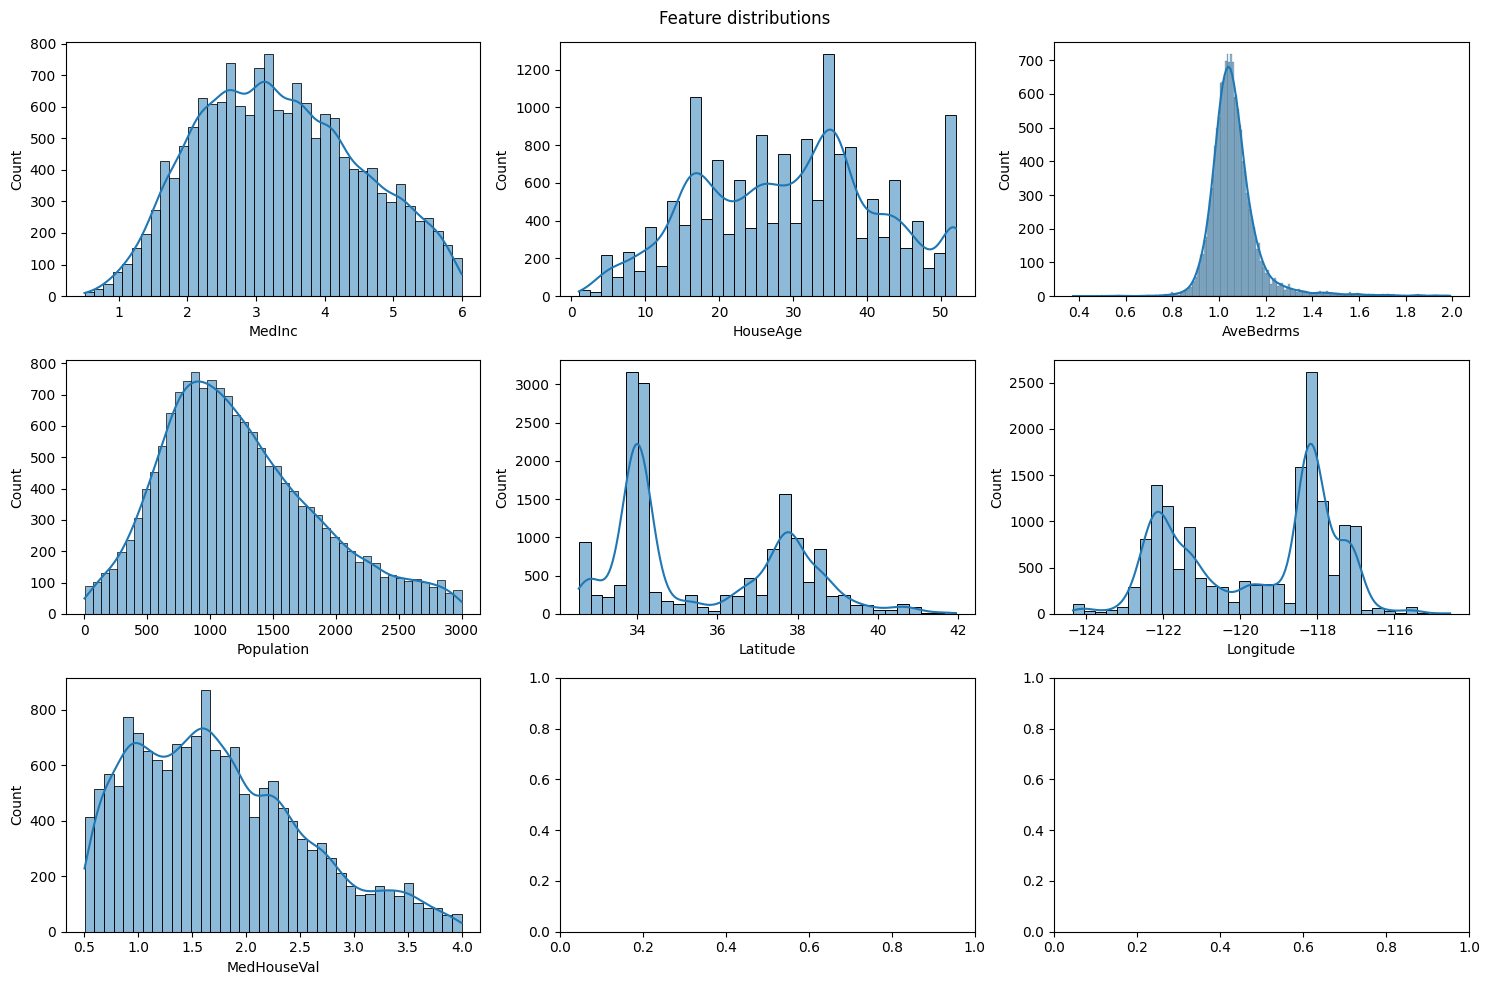

In [52]:
from sklearn.preprocessing import StandardScaler

data_filtered = data.query(('MedInc < 6 and MedHouseVal < 4 and MedHouseVal > 0.5 \
    and AveBedrms < 2 and Population < 3000')).drop(columns=['AveOccup', 'AveRooms'])
print(len(data_filtered))


fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('Feature distributions')
for i, axe in enumerate(axes.ravel()):
    if i < len(data_filtered.columns):
        col = data_filtered.columns[i]
        sns.histplot(data_filtered[col], kde=True, ax=axe)
    else:
        break
plt.tight_layout()


# fig3, axes3 = plt.subplots(figsize=(10, 6))
# sns.heatmap(data_filtered.corr(), annot=True, ax=axes3, fmt=".2f", cmap="coolwarm")
# axes3.set_title('Correlation Matrix')

plt.tight_layout()



In [70]:

from sklearn.model_selection import train_test_split

X, y = data_filtered.drop(columns=['MedHouseVal']), data_filtered['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3)


y_train = np.log(y_train)
y_test = np.log(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [71]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 0.24329061  0.03138528  0.03934777  0.00886366 -0.59373805 -0.54711915]
Intercept: 0.44806887561291064


In [72]:
from sklearn.metrics import r2_score, mean_squared_error

print(f"R2 = {r2_score(y_test, y_pred)}")
print(f"MSE = {mean_squared_error(y_test, y_pred)}")

R2 = -0.5535433444465485
MSE = 0.34930993758760764


Text(0.5, 1.0, 'Test Evaluation')

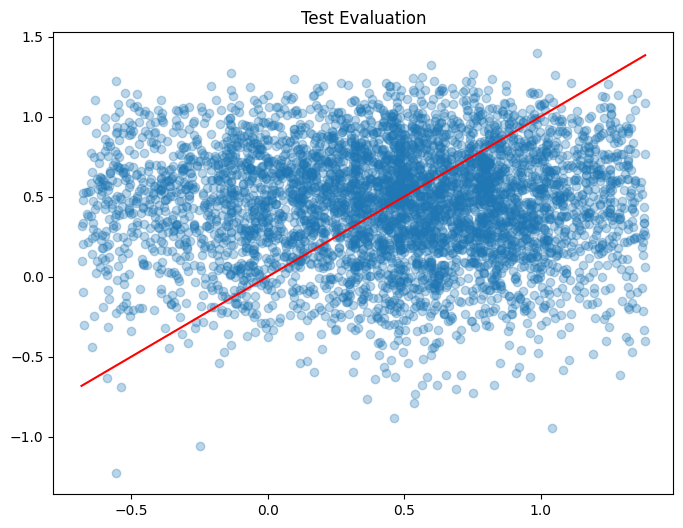

In [73]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=.3)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Test Evaluation')

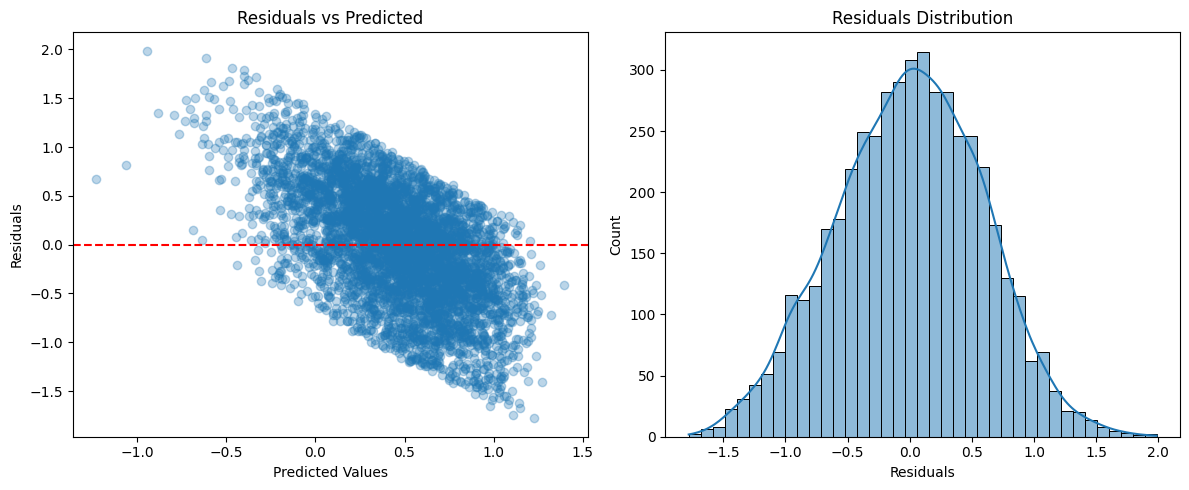

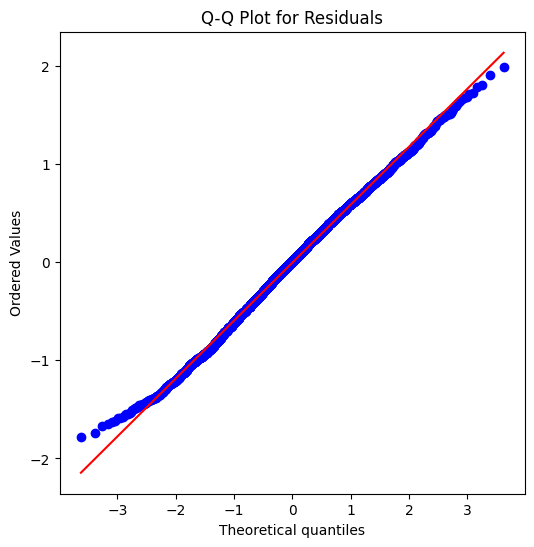

In [74]:
residuals = y_test - y_pred
from scipy import stats
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

# Histogram of residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.tight_layout()
plt.show()

# Q-Q plot for normality
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot for Residuals')
plt.show()